<p>インポート</p>

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [131]:
import matplotlib_fontja

In [132]:
import pingouin as pg

In [133]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [134]:
from itertools import product
from linearmodels.panel import PanelOLS

<p>データの読み取り</p>

In [135]:
#df = pd.read_excel("data/testdata.xlsx", sheet_name="Sheet2")
df = pd.read_csv("data/election_data.csv")
df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合
0,あきる野市,議員,2013/6/23,21,60.0,35.0,0,0,0.190476,0.333333,0.238095,0.142857,0.523810
1,あきる野市,議員,2017/6/11,21,52.0,39.0,15,6,0.285714,0.238095,0.190476,0.142857,0.571429
2,あきる野市,首長,2015/10/4,1,66.0,66.0,1,0,1.000000,1.000000,0.000000,0.000000,1.000000
3,あきる野市,首長,2019/10/6,1,62.0,62.0,1,0,1.000000,0.000000,0.000000,0.000000,1.000000
4,あさぎり町,議員,2012/4/22,16,59.5,50.0,14,2,0.312500,0.062500,0.000000,0.000000,1.000000


In [136]:
df_statistics = pd.read_csv('data/local_gov_statistics.csv')
df_statistics.head()

,地域コード,年度,15~64歳人口,15~64歳人口(女),15~64歳人口(男),15歳未満人口,15歳未満人口(女),15歳未満人口(男),65歳以上の世帯員のいる核家族世帯数,65歳以上世帯員の単独世帯数,...,離婚件数,非労働力人口,非労働力人口(女),非労働力人口(男),非水洗化人口,飲食店数,高等学校数,高等学校生徒数,高齢単身世帯数(65歳以上の者1人),高齢夫婦のみの世帯数
0,R01100,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9124.0,NaN,NaN,NaN,NaN
1,R01100,2015,1235516.0,645405.0,590111.0,221013.0,108270.0,112743.0,178246.0,NaN,...,NaN,651052.0,435482.0,215570.0,7169.0,NaN,NaN,NaN,104650.0,98660.0
2,R01100,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4096.0,NaN,NaN,NaN,7107.0,8502.0,53.0,44774.0,NaN,NaN
3,R01100,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4003.0,NaN,NaN,NaN,6549.0,NaN,52.0,44201.0,NaN,NaN
4,R01100,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4024.0,NaN,NaN,NaN,6363.0,NaN,52.0,44345.0,NaN,NaN


In [137]:
df_region_code = pd.read_csv('data/region_code_correspondence.csv')
df_region_code.head()

,地域コード,都道府県,市区町村
0,R01100,北海道,札幌市
1,R01202,北海道,函館市
2,R01203,北海道,小樽市
3,R01204,北海道,旭川市
4,R01205,北海道,室蘭市


<p>65歳以上人口のみのdfを作成<p>

In [138]:
abv65_df = df_statistics.loc[:,('地域コード','年度','総人口','65歳以上人口')]

In [139]:
abv65_df['65歳以上人口割合'] = abv65_df['65歳以上人口'] / abv65_df['総人口']

In [140]:
abv65_meandf = abv65_df.groupby('地域コード')['65歳以上人口割合'].mean().reset_index()

In [141]:
abv65_meandf = abv65_meandf.merge(df_region_code, on='地域コード', how='left', validate='one_to_one')

<p>それぞれのdfの結びつけ</p>

In [142]:
merged_df = df.merge(abv65_meandf.drop(columns=['都道府県']), on="市区町村", how="left")

<p>議員データと首長データの分離</p>

In [143]:
merged_df['日付'] = pd.to_datetime(merged_df['日付'], format='%Y/%m/%d')  
merged_df['年'] = merged_df['日付'].dt.year

In [144]:
counciler_df = merged_df[merged_df['種別'] == '議員']
chief_df = merged_df[merged_df['種別'] == '首長']

In [145]:
counciler_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年
0,あきる野市,議員,2013-06-23,21,60.0,35.0,0,0,0.190476,0.333333,0.238095,0.142857,0.523810,R13228,0.289397,2013
1,あきる野市,議員,2017-06-11,21,52.0,39.0,15,6,0.285714,0.238095,0.190476,0.142857,0.571429,R13228,0.289397,2017
4,あさぎり町,議員,2012-04-22,16,59.5,50.0,14,2,0.312500,0.062500,0.000000,0.000000,1.000000,R43514,0.364495,2012
5,あさぎり町,議員,2016-04-24,16,61.0,42.0,13,3,0.125000,0.187500,0.000000,0.000000,1.000000,R43514,0.364495,2016
6,あさぎり町,議員,2020-04-26,14,63.5,53.0,11,3,0.071429,0.428571,0.000000,0.000000,1.000000,R43514,0.364495,2020


<p>可視化<p>
<ul>
<li>それぞれのヒストグラム</li>
<li>新人割合と65歳以上の議員割合の相関</li>
<li>住んでいる人の65歳以上割合と議員の65歳以上割合の相関</li>
<li>それぞれの都市での議員と首長の時系列的な折れ線グラフ</li>
</ul>


c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

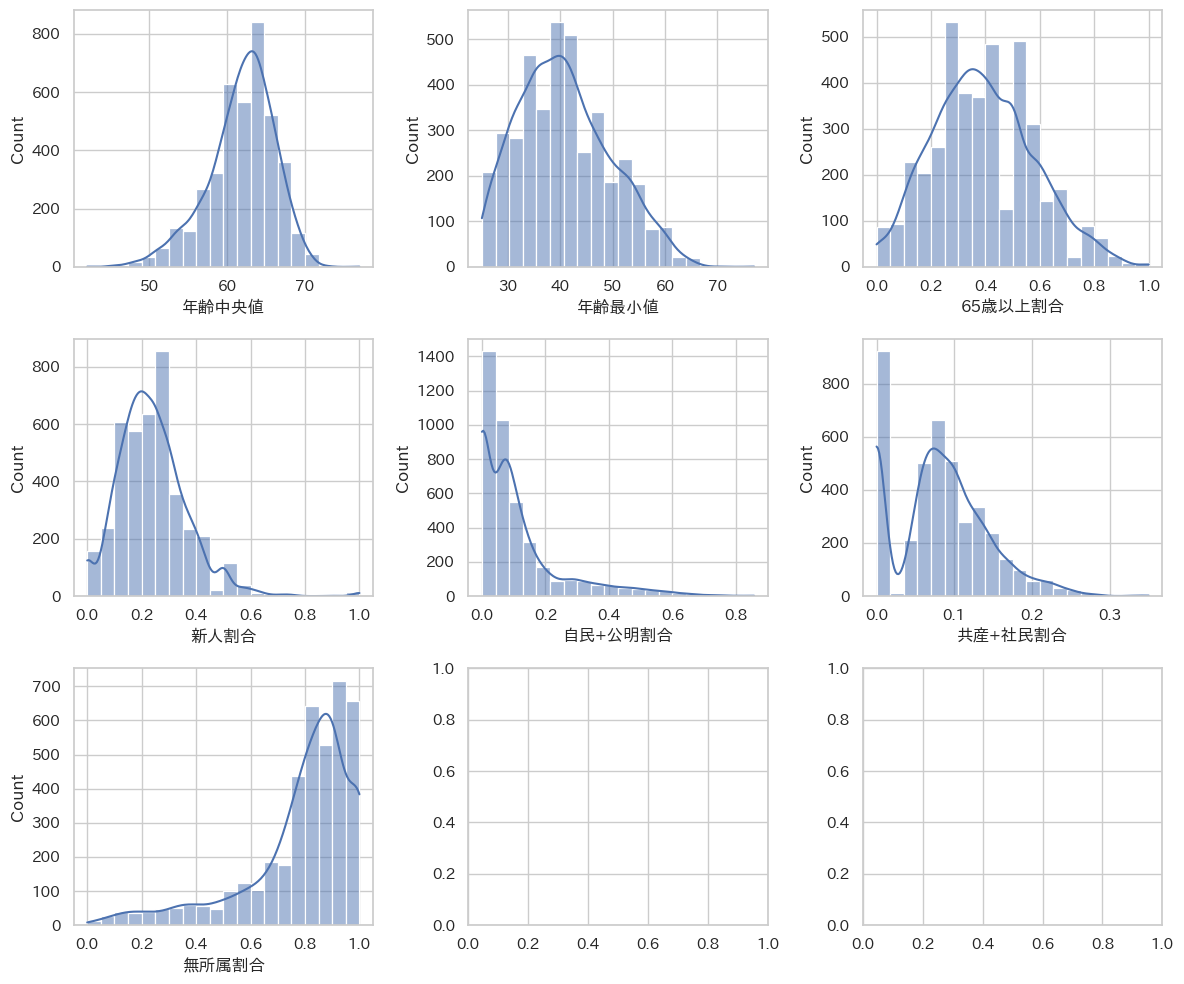

In [146]:
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'IPAexGothic'

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.histplot(data=counciler_df, x="年齢中央値", bins=20, kde=True, ax=axes[0, 0])
sns.histplot(data=counciler_df, x="年齢最小値", bins=20, kde=True, ax=axes[0, 1])
sns.histplot(data=counciler_df, x="65歳以上割合", bins=20, kde=True, ax=axes[0, 2])
sns.histplot(data=counciler_df, x="新人割合", bins=20, kde=True, ax=axes[1, 0])
sns.histplot(data=counciler_df, x="自民+公明割合", bins=20, kde=True, ax=axes[1, 1])
sns.histplot(data=counciler_df, x="共産+社民割合", bins=20, kde=True, ax=axes[1, 2])
sns.histplot(data=counciler_df, x="無所属割合", bins=20, kde=True, ax=axes[2,0])

plt.tight_layout()
plt.show()

c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\nshun\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

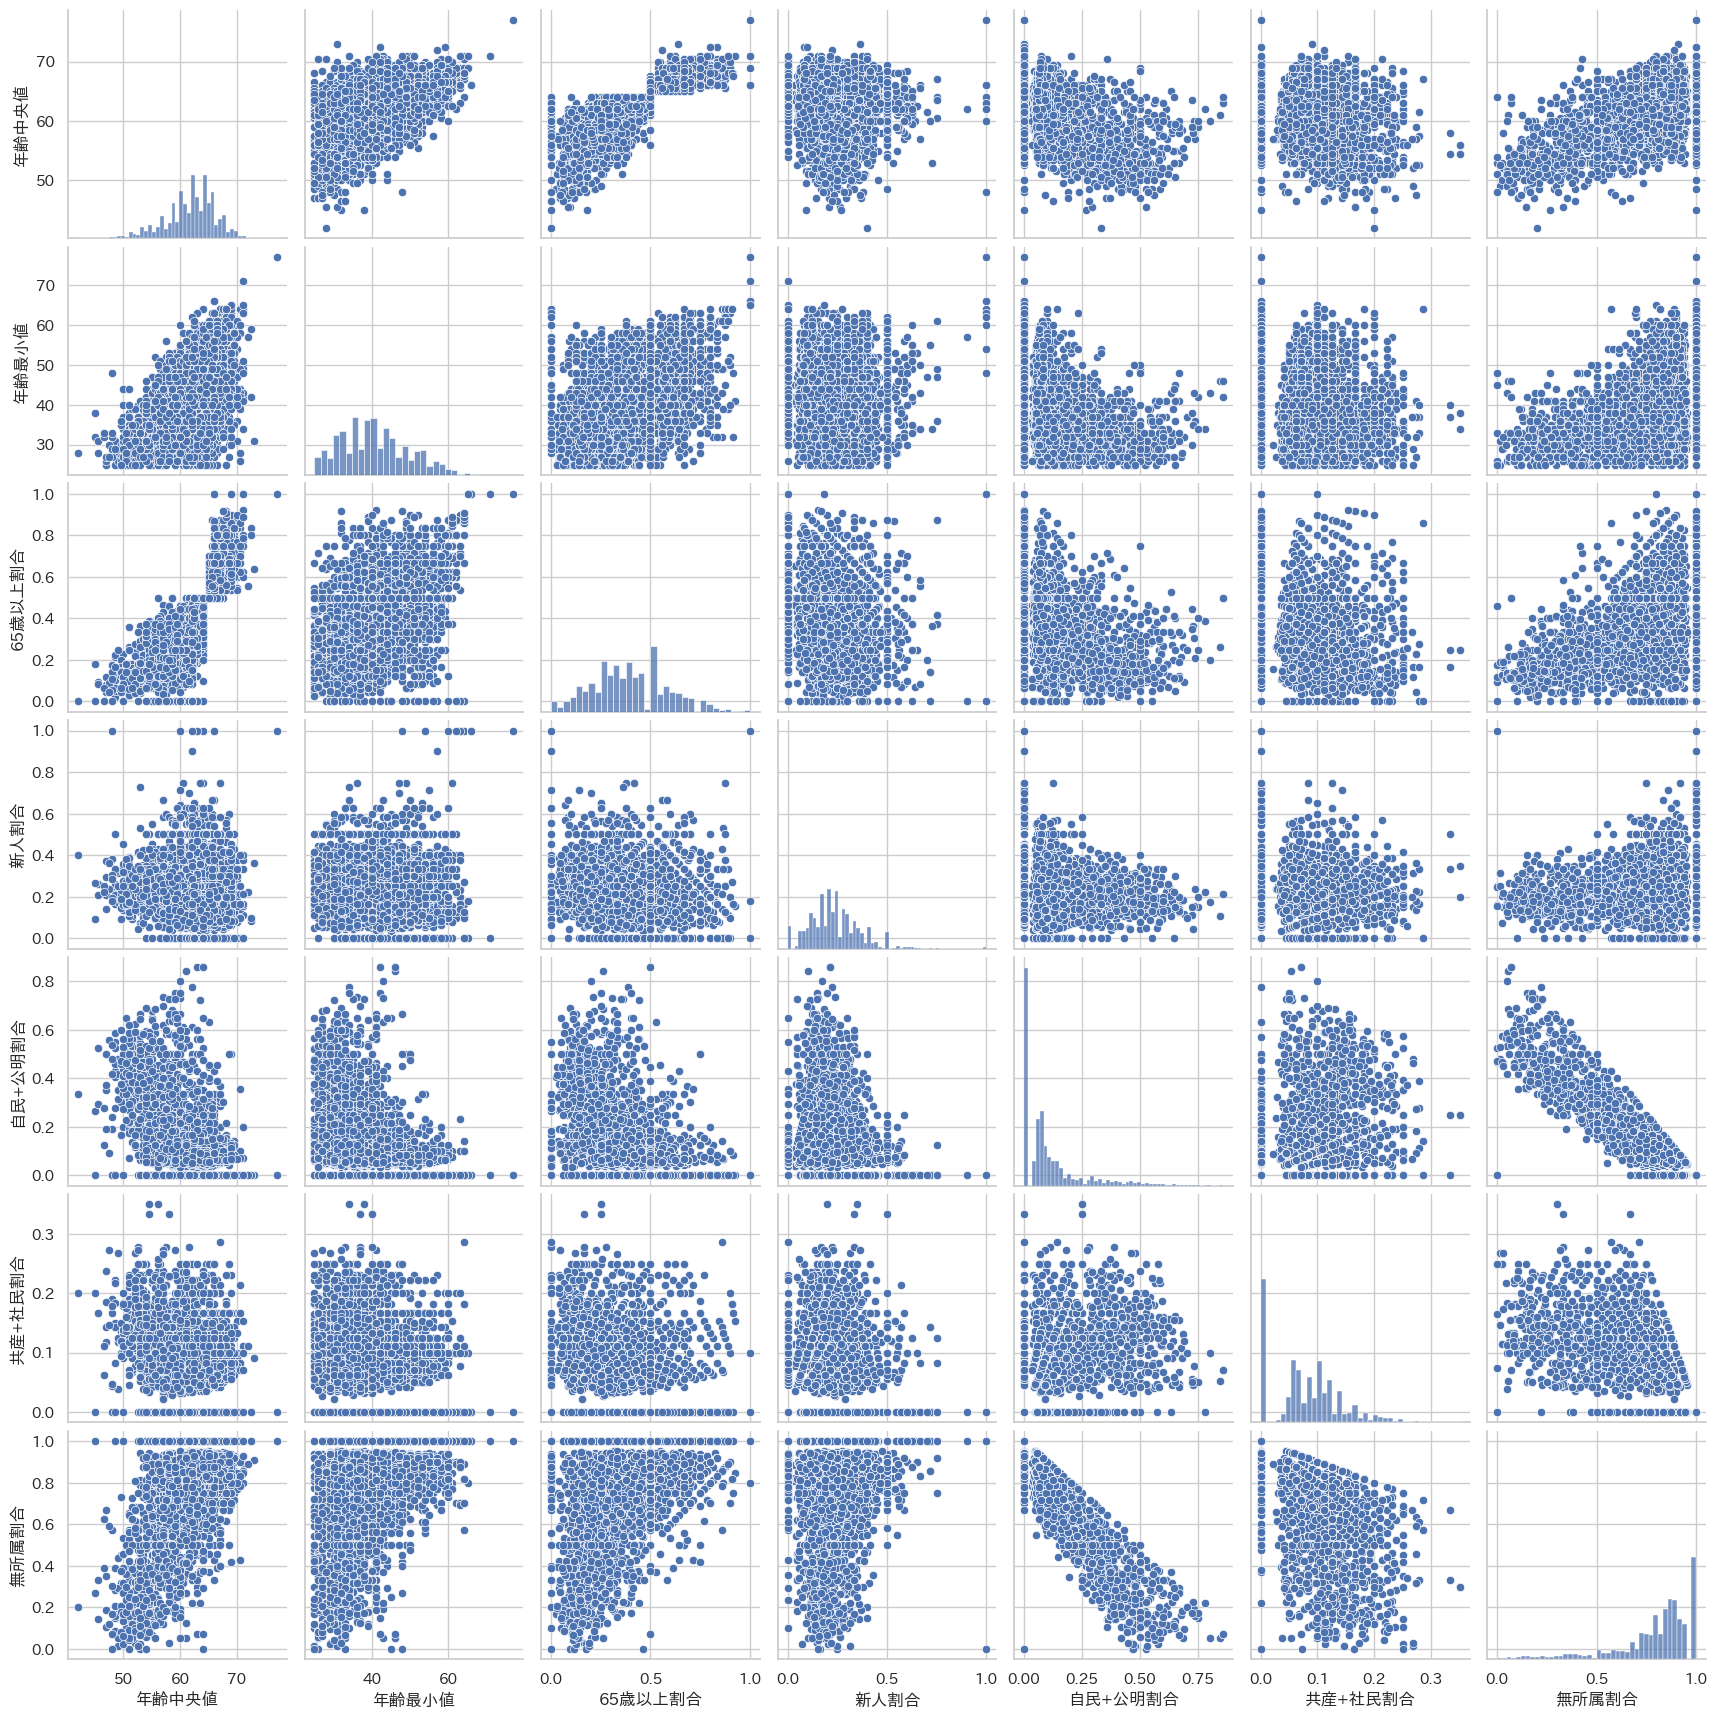

In [147]:
sns.pairplot(counciler_df[["年齢中央値", "年齢最小値", "65歳以上割合", "新人割合", "自民+公明割合", "共産+社民割合", "無所属割合"]])
plt.show()

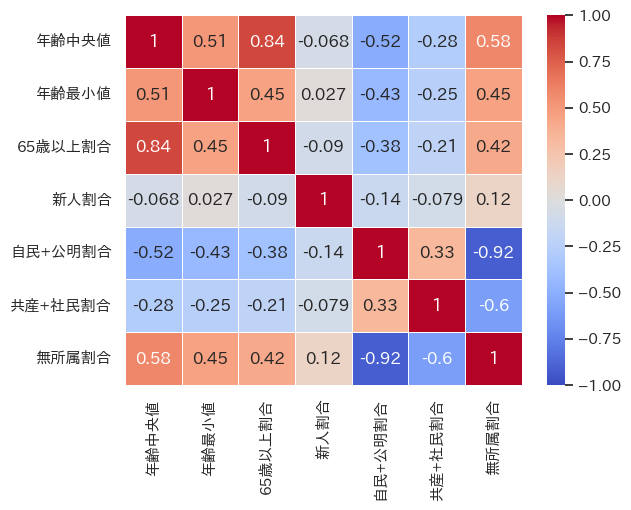

In [148]:
sns.heatmap(counciler_df.loc[:, ['年齢中央値', '年齢最小値', '65歳以上割合', '新人割合', '自民+公明割合', '共産+社民割合', '無所属割合']].corr(), annot=True, cmap='coolwarm',linewidths=0.5, vmin=-1, vmax=1)
plt.show()

In [149]:
partial_corr_matrix = counciler_df.loc[counciler_df['男性'] > 0, ['年齢中央値', '年齢最小値','男性', '65歳以上割合', '新人割合', '自民+公明割合', '共産+社民割合', '無所属割合']].pcorr()

print("偏相関係数行列:")
print(partial_corr_matrix)

偏相関係数行列:
            年齢中央値     年齢最小値        男性   65歳以上割合      新人割合   自民+公明割合   共産+社民割合  \
年齢中央値    1.000000  0.142357 -0.015497  0.763708 -0.062468  0.158558  0.173239   
年齢最小値    0.142357  1.000000 -0.248526  0.066436 -0.003358 -0.045497 -0.043724   
男性      -0.015497 -0.248526  1.000000 -0.062214 -0.147211  0.097223 -0.016797   
65歳以上割合  0.763708  0.066436 -0.062214  1.000000 -0.066130 -0.069554 -0.074753   
新人割合    -0.062468 -0.003358 -0.147211 -0.066130  1.000000 -0.053965 -0.043204   
自民+公明割合  0.158558 -0.045497  0.097223 -0.069554 -0.053965  1.000000 -0.698286   
共産+社民割合  0.173239 -0.043724 -0.016797 -0.074753 -0.043204 -0.698286  1.000000   
無所属割合    0.284188 -0.011973 -0.053301 -0.124366 -0.018929 -0.925902 -0.795136   

            無所属割合  
年齢中央値    0.284188  
年齢最小値   -0.011973  
男性      -0.053301  
65歳以上割合 -0.124366  
新人割合    -0.018929  
自民+公明割合 -0.925902  
共産+社民割合 -0.795136  
無所属割合    1.000000  


In [150]:
def plot_temporal_trajectory(df, x_col, y_col, time_col, group_col, ax=None, title=None):
    """
    時間経過に伴う散布図の推移を矢印で結んで描画する関数

    Parameters:
    -----------
    df : pandas.DataFrame
        描画対象のデータフレーム
    x_col : str
        X軸に指定するカラム名
    y_col : str
        Y軸に指定するカラム名
    time_col : str
        時間経過を表すカラム名（色分けと矢印の順序に使用）
    group_col : str
        各軌跡をグループ化するカラム名（市区町村など。ラベルにも使用）
    ax : matplotlib.axes.Axes, optional
        描画対象のAxes（subplot用）。指定がない場合は現在のAxesを使用。
    title : str, optional
        グラフのタイトル
    """
    # axが指定されていない場合は現在のAxesを取得
    if ax is None:
        ax = plt.gca()

    # 矢印が過去→未来へ向かうように、グループと時間でソート
    df_sorted = df.sort_values(by=[group_col, time_col])

    # 散布図の描画 (引数に ax=ax を指定する)
    sns.scatterplot(
        data=df_sorted, 
        x=x_col, 
        y=y_col, 
        hue=time_col, 
        palette="viridis",
        ax=ax
    )

    # グループ（市区町村など）ごとに矢印とラベルを描画
    for name, group in df_sorted.groupby(group_col):
        xs = group[x_col].values
        ys = group[y_col].values
        
        # 矢印を描画
        for i in range(len(xs) - 1):
            ax.annotate(
                '', 
                xy=(xs[i+1], ys[i+1]), 
                xytext=(xs[i], ys[i]), 
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6, lw=1.2)
            )
            
        # 最新の年にラベルを描画
        if len(xs) > 0:
            ax.annotate(
                name, 
                (xs[-1], ys[-1]), 
                fontsize=8, 
                xytext=(3, 3), 
                textcoords="offset points"
            )

    # 軸ラベルとタイトルの設定
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    if title:
        ax.set_title(title)

    # 凡例の調整
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    return ax

In [151]:
# # 1行2列の図（Figure）と軸（Axes）の配列を作成
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # --- 左側のグラフ (axes[0] に描画) ---
# # ※ counciler_df から特定の条件で絞り込んだデータなどを渡します
# df_subset_A = counciler_df

# plot_temporal_trajectory(
#     df=df_subset_A,
#     x_col="65歳以上割合",
#     y_col="新人割合",
#     time_col="年",
#     group_col="市区町村",
#     ax=axes[0],            # ← ここで左側のエリアを指定
#     title="65歳以上人口割合と新人割合の推移"
# )

# # --- 右側のグラフ (axes[1] に描画) ---
# df_subset_B = counciler_df

# plot_temporal_trajectory(
#     df=df_subset_B,
#     x_col="自民+公明割合",
#     y_col="新人割合",
#     time_col="年",
#     group_col="市区町村",
#     ax=axes[1],            # ← ここで右側のエリアを指定
#     title="自民+公明割合と新人割合の推移"
# )

# # レイアウトの自動調整（グラフ同士や凡例の重なりを防ぐ）
# plt.tight_layout()

# # 表示
# plt.show()

In [152]:
# # 散布図
# sns.scatterplot(data=counciler_df[counciler_df['年'] > 2019], x="65歳以上割合", y="65歳以上人口割合")

# # 各点に市区町村名をラベル表示
# for i, row in counciler_df[counciler_df['年'] > 2019].iterrows():
#     plt.annotate(row["市区町村"], 
#                  (row["65歳以上割合"], row["65歳以上人口割合"]),
#                  fontsize=8,       # 文字サイズ
#                  xytext=(3,3),     # 文字の位置微調整
#                  textcoords="offset points")

# plt.xlabel("65歳以上割合")
# plt.ylabel("65歳以上人口割合")
# plt.title("65歳以上割合 vs 65歳以上人口割合（市区町村別）")
# plt.show()

In [153]:
ress = counciler_df["65歳以上割合"].corr(counciler_df["新人割合"])
print(f"65歳以上割合と新人割合の相関係数: {ress:.2f}")

65歳以上割合と新人割合の相関係数: -0.09


In [154]:
# # 全体の日付範囲を作る
# full_date_range = pd.date_range(start='2011-01-01', end='2023-11-30', freq='D')

# # 時系列補完関数（指定日付範囲で前値保持）
# def create_city_time_series(df, value_col='年齢中央値', date_range=full_date_range):
#     all_ts = pd.DataFrame(index=date_range)
#     for city, g in df.groupby('市区町村'):
#         g = g.sort_values('日付').set_index('日付')
#         ts = g[value_col].reindex(date_range).ffill()  # 前値補完
#         all_ts[city] = ts
#     return all_ts

# # 議員・首長の時系列
# counciler_ts = create_city_time_series(counciler_df)
# chief_ts = create_city_time_series(chief_df)

# counciler_ts = counciler_ts.loc['2015-01-01':,:]
# chief_ts = chief_ts.loc['2015-01-01':,:]

# # グラフ作成
# plt.figure(figsize=(14,7))

# # 議員を青系で描画
# sns.lineplot(data=counciler_ts, palette="Blues", linewidth=2, legend=True)

# # 首長を赤系で描画
# sns.lineplot(data=chief_ts, palette="Reds", linewidth=2, legend=True)

# plt.xlabel("日付")
# plt.ylabel("年齢中央値")
# plt.title("市区町村ごとの議員（青）と首長（赤）の年齢中央値時系列")
# plt.grid(True)
# plt.show()

<p>欠損値の埋め合わせ</p>
<p>-男女のデータの埋め合わせが必須</p>

In [155]:
zero_mask = (counciler_df['男性'] == 0) & (counciler_df['女性'] == 0)

def fill_male_female(group):
    group = group.sort_values('日付').copy()
    group['男性'] = group['男性'].replace(0, np.nan).ffill().bfill()
    group['女性'] = group['女性'].replace(0, np.nan).ffill().bfill()
    return group

counciler_df = counciler_df.groupby('市区町村', group_keys=False).apply(fill_male_female)

C:\Users\nshun\AppData\Local\Temp\ipykernel_444\1637797231.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  counciler_df = counciler_df.groupby('市区町村', group_keys=False).apply(fill_male_female)


In [156]:
counciler_df['男女比率'] = counciler_df['女性'] / (counciler_df['女性'] + counciler_df['男性'])

In [157]:
counciler_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年,男女比率
0,あきる野市,議員,2013-06-23,21,60.0,35.0,15.0,6.0,0.190476,0.333333,0.238095,0.142857,0.523810,R13228,0.289397,2013,0.285714
1,あきる野市,議員,2017-06-11,21,52.0,39.0,15.0,6.0,0.285714,0.238095,0.190476,0.142857,0.571429,R13228,0.289397,2017,0.285714
4,あさぎり町,議員,2012-04-22,16,59.5,50.0,14.0,2.0,0.312500,0.062500,0.000000,0.000000,1.000000,R43514,0.364495,2012,0.125000
5,あさぎり町,議員,2016-04-24,16,61.0,42.0,13.0,3.0,0.125000,0.187500,0.000000,0.000000,1.000000,R43514,0.364495,2016,0.187500
6,あさぎり町,議員,2020-04-26,14,63.5,53.0,11.0,3.0,0.071429,0.428571,0.000000,0.000000,1.000000,R43514,0.364495,2020,0.214286


In [158]:
chief_df.head()

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年
2,あきる野市,首長,2015-10-04,1,66.0,66.0,1,0,1.0,1.0,0.0,0.0,1.0,R13228,0.289397,2015
3,あきる野市,首長,2019-10-06,1,62.0,62.0,1,0,1.0,0.0,0.0,0.0,1.0,R13228,0.289397,2019
7,あさぎり町,首長,2015-04-26,1,67.0,67.0,1,0,0.0,1.0,0.0,0.0,1.0,R43514,0.364495,2015
8,あさぎり町,首長,2019-04-21,1,69.0,69.0,1,0,1.0,1.0,0.0,0.0,1.0,R43514,0.364495,2019
11,あま市,首長,2014-04-13,1,51.0,51.0,1,0,0.0,0.0,0.0,0.0,1.0,R23237,0.260814,2014


In [159]:
counciler_df.describe()

,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,65歳以上人口割合,年,男女比率
count,4087,4087.000000,4053.000000,4053.000000,3960.000000,3548.000000,4087.000000,4087.000000,4087.000000,4087.000000,4087.000000,4043.000000,4087.000000,3548.000000
mean,2017-01-27 21:18:58.928309248,17.275263,61.829509,40.746854,14.839394,2.689402,0.238529,0.391728,0.107964,0.081547,0.783582,0.334905,2016.652802,0.144243
min,2012-01-22 00:00:00,1.000000,42.000000,25.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.102715,2012.000000,0.030303
25%,2015-04-26 00:00:00,12.000000,59.500000,34.000000,10.000000,1.000000,0.153846,0.250000,0.000000,0.045455,0.722222,0.278919,2015.000000,0.083333
50%,2017-03-19 00:00:00,16.000000,62.500000,40.000000,13.000000,2.000000,0.222222,0.375000,0.071429,0.083333,0.833333,0.332719,2017.000000,0.125000
75%,2019-04-21 00:00:00,20.000000,65.000000,47.000000,17.000000,3.000000,0.300000,0.500000,0.136364,0.117647,0.916667,0.382862,2019.000000,0.187500
max,2021-12-19 00:00:00,81.000000,77.000000,77.000000,68.000000,22.000000,1.000000,1.000000,0.857143,0.350000,1.000000,0.786419,2021.000000,0.950000
std,NaN,8.549549,4.307661,8.799935,6.874876,2.360738,0.128617,0.186983,0.137714,0.060303,0.207046,0.076425,2.562691,0.083795


In [160]:
counciler_df.loc[counciler_df['男性'] == 68,:]

,市区町村,種別,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,地域コード,65歳以上人口割合,年,男女比率
5099,横浜市,議員,2015-04-12,80,51.0,33.0,68.0,12.0,0.125,0.1375,0.5875,0.1125,0.05,R14100,0.238029,2015,0.15


In [161]:
chief_df.describe()

,日付,候補者数,年齢中央値,年齢最小値,男性,女性,新人割合,65歳以上割合,自民+公明割合,共産+社民割合,無所属割合,65歳以上人口割合,年
count,4525,4525.0,4522.000000,4522.000000,4525.000000,4525.000000,4525.000000,4525.000000,4525.000000,4525.000000,4525.000000,4479.000000,4525.000000
mean,2016-11-26 17:44:29.171270656,1.0,61.610128,61.610128,0.970166,0.016354,0.315138,0.412597,0.043315,0.005525,0.947182,0.335538,2016.429834
min,2012-01-15 00:00:00,1.0,28.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.102715,2012.000000
25%,2014-04-20 00:00:00,1.0,57.250000,57.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.279533,2014.000000
50%,2017-01-15 00:00:00,1.0,63.000000,63.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.332947,2017.000000
75%,2019-04-21 00:00:00,1.0,67.000000,67.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.384506,2019.000000
max,2021-12-26 00:00:00,1.0,86.000000,86.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.786419,2021.000000
std,NaN,0.0,8.496218,8.496218,0.170149,0.126845,0.464622,0.492356,0.203588,0.074132,0.223694,0.076980,2.813735


主成分分析以外の手法にもトライして頑健性を確かめたい

<p>主成分分析による次元削減<p>

<ol>
<li>データの形成</li>
<li>標準化</li>
<li>主成分分析</li>
<li>可視化</li>
</ol>

<p>1</p>

<p>議会</p>

In [162]:
counciler_df['65pp'] = counciler_df['65歳以上割合'] - counciler_df['65歳以上人口割合']

In [163]:
#pca_df = counciler_df[['年齢最小値','65pp', '新人割合', '男女比率','自民+公明割合','共産+社民割合','無所属割合']].dropna()
pca_df = counciler_df[['65pp', '新人割合', '男女比率','自民+公明割合','共産+社民割合','無所属割合']].dropna()

In [164]:
pca_df.head(6)

,65pp,新人割合,男女比率,自民+公明割合,共産+社民割合,無所属割合
0,0.043936,0.190476,0.285714,0.238095,0.142857,0.523810
1,-0.051302,0.285714,0.285714,0.190476,0.142857,0.571429
4,-0.301995,0.312500,0.125000,0.000000,0.000000,1.000000
5,-0.176995,0.125000,0.187500,0.000000,0.000000,1.000000
6,0.064077,0.071429,0.214286,0.000000,0.000000,1.000000
9,0.072519,0.291667,0.041667,0.125000,0.083333,0.791667


<p>首長</p>

In [165]:
pca_df_cheif = chief_df[['年齢最小値','新人割合', '男性','自民+公明割合','共産+社民割合','無所属割合']].dropna()

In [166]:
pca_df_cheif.head(5)

,年齢最小値,新人割合,男性,自民+公明割合,共産+社民割合,無所属割合
2,66.0,1.0,1,0.0,0.0,1.0
3,62.0,1.0,1,0.0,0.0,1.0
7,67.0,0.0,1,0.0,0.0,1.0
8,69.0,1.0,1,0.0,0.0,1.0
11,51.0,0.0,1,0.0,0.0,1.0


<p>2</p>

<p>議員</p>

In [167]:
scaler = StandardScaler()
scaler.fit(pca_df)

,copy,True
,with_mean,True
,with_std,True


In [168]:
pca_df_std = scaler.transform(pca_df)

<p>首長</p>

In [169]:
scaler_ch = StandardScaler()
scaler_ch.fit(pca_df_cheif)

,copy,True
,with_mean,True
,with_std,True


In [170]:
pca_df_cheif_std = scaler_ch.transform(pca_df_cheif)

<p>3</p>

<p>議員</p>

In [171]:
pca = PCA(n_components=2)
pca.fit(pca_df_std)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [172]:
pca_fitted = pca.transform(pca_df_std)

In [173]:
# A. 寄与率（Explained Variance Ratio）
# 各主成分がデータ全体の情報をどれだけ持っているか
ev_ratio = pca.explained_variance_ratio_
cum_ev_ratio = np.cumsum(ev_ratio)

print("【議員ー寄与率】")
for i, ratio in enumerate(ev_ratio):
    print(f"第{i+1}主成分: {ratio:.2%}")
print(f"累積寄与率: {cum_ev_ratio[-1]:.2%}\n")

# B. 主成分負荷量（Loadings）
# 各変数が主成分（軸）に与えている影響力
# pca.components_ は (主成分数, 変数数) の形状なので転置してDataFrame化
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("【議員ー主成分負荷量】")
print(loadings)

【議員ー寄与率】
第1主成分: 42.63%
第2主成分: 18.88%
累積寄与率: 61.51%

【議員ー主成分負荷量】
        PC1       PC2
0  0.234459 -0.434868
1  0.091124  0.822426
2 -0.318218  0.333337
3 -0.543689 -0.124199
4 -0.418814 -0.049234
5  0.603705  0.074447


<p>首長</p>

首長は同じようにはできないので変更が必要

In [174]:
pca_ch = PCA(n_components=2)
pca_ch.fit(pca_df_cheif_std)
pca_ch_fitted = pca_ch.transform(pca_df_cheif_std)

In [175]:
ev_ratio_ch = pca_ch.explained_variance_ratio_
cum_ev_ratio_ch = np.cumsum(ev_ratio_ch)

print("【首長ー寄与率】")
for i, ratio in enumerate(ev_ratio_ch):
    print(f"第{i+1}主成分: {ratio:.2%}")
print(f"累積寄与率: {cum_ev_ratio_ch[-1]:.2%}\n")

loadings2 = pd.DataFrame(
    pca_ch.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_ch.n_components_)]
)

print("【首長ー主成分負荷量】")
print(loadings2)

【首長ー寄与率】
第1主成分: 34.06%
第2主成分: 22.04%
累積寄与率: 56.10%

【首長ー主成分負荷量】
        PC1       PC2
0  0.070917  0.684653
1 -0.011135 -0.674890
2  0.018875  0.265684
3 -0.653321  0.056180
4 -0.340574  0.042591
5  0.672065 -0.014693


<p>4</p>

In [176]:
pca_results_df = pd.DataFrame(
    pca_fitted, 
    columns=['PC1', 'PC2'], 
    index=pca_df.index
)

pca_results_ch_df = pd.DataFrame(
    pca_ch_fitted,
    columns=['PC1', 'PC2'],
    index=pca_df_cheif.index
)

In [177]:
pca_results_df['市区町村'] = counciler_df.loc[pca_df.index, '市区町村']
pca_results_df['年度'] = counciler_df.loc[pca_df.index, '日付'].dt.year

pca_results_ch_df['市区町村'] = chief_df.loc[pca_df_cheif.index, '市区町村']
pca_results_ch_df['年度'] = chief_df.loc[pca_df_cheif.index, '日付'].dt.year

In [178]:
print("--- PCAスコア議員（各自治体の位置） ---")
print(pca_results_df.head())

print('--------------------------------------')

print("--- PCAスコア首長（各自治体の位置） ---")
print(pca_results_ch_df.head())

--- PCAスコア議員（各自治体の位置） ---
        PC1       PC2   市区町村    年度
0 -2.185531  0.023432  あきる野市  2013
1 -1.920045  0.953308  あきる野市  2017
4  1.365473  1.566459  あさぎり町  2012
5  1.160895  0.258695  あさぎり町  2016
6  1.347397 -0.596587  あさぎり町  2020
--------------------------------------
--- PCAスコア首長（各自治体の位置） ---
         PC1       PC2   市区町村    年度
2   0.346764 -0.612637  あきる野市  2015
3   0.313373 -0.935005  あきる野市  2019
7   0.379077  0.920412  あさぎり町  2015
8   0.371808 -0.370860  あさぎり町  2019
11  0.245511 -0.369064    あま市  2014


In [179]:
pca_results_df['期'] = 1
pca_results_ch_df['期'] = 1

In [180]:
unique_cities = pca_results_df['市区町村'].unique()
combinations = list(product(unique_cities, [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]))
PCA_df_final = pd.DataFrame(combinations, columns=['市区町村', '年度'])

PCA_df_final = PCA_df_final.merge(pca_results_df.rename(columns={'PC1': 'CPC1', 'PC2': 'CPC2'}), on=['市区町村', '年度'], how='left').rename(columns={'期': '期（議員）'})
PCA_df_final = PCA_df_final.merge(pca_results_ch_df.rename(columns={'PC1': 'CHPC1', 'PC2': 'CHPC2'}), on=['市区町村', '年度'], how='left').rename(columns={'期': '期（首長）'})

base = PCA_df_final['期（議員）'].ffill()
group_id = PCA_df_final['期（議員）'].notna().cumsum()
increment = PCA_df_final['期（議員）'].isna().groupby(group_id).cumsum()
PCA_df_final['期（議員）'] = base + increment

base = PCA_df_final['期（首長）'].ffill()
group_id = PCA_df_final['期（首長）'].notna().cumsum()
increment = PCA_df_final['期（首長）'].isna().groupby(group_id).cumsum()
PCA_df_final['期（首長）'] = base + increment


PCA_ffill_df = PCA_df_final.groupby('市区町村')[['CPC1', 'CPC2', 'CHPC1', 'CHPC2']].ffill()


PCA_df_final['CPC1'] = PCA_ffill_df['CPC1']
PCA_df_final['CPC2'] = PCA_ffill_df['CPC2']
PCA_df_final['CHPC1'] = PCA_ffill_df['CHPC1']   
PCA_df_final['CHPC2'] = PCA_ffill_df['CHPC2']

PCA_df_final = PCA_df_final[PCA_df_final['年度'] >= 2015].reset_index(drop=True)

In [181]:
PCA_df_final.head()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
0,あきる野市,2015,-2.185531,0.023432,3.0,0.346764,-0.612637,1.0
1,あきる野市,2016,-2.185531,0.023432,4.0,0.346764,-0.612637,2.0
2,あきる野市,2017,-1.920045,0.953308,1.0,0.346764,-0.612637,3.0
3,あきる野市,2018,-1.920045,0.953308,2.0,0.346764,-0.612637,4.0
4,あきる野市,2019,-1.920045,0.953308,3.0,0.313373,-0.935005,1.0


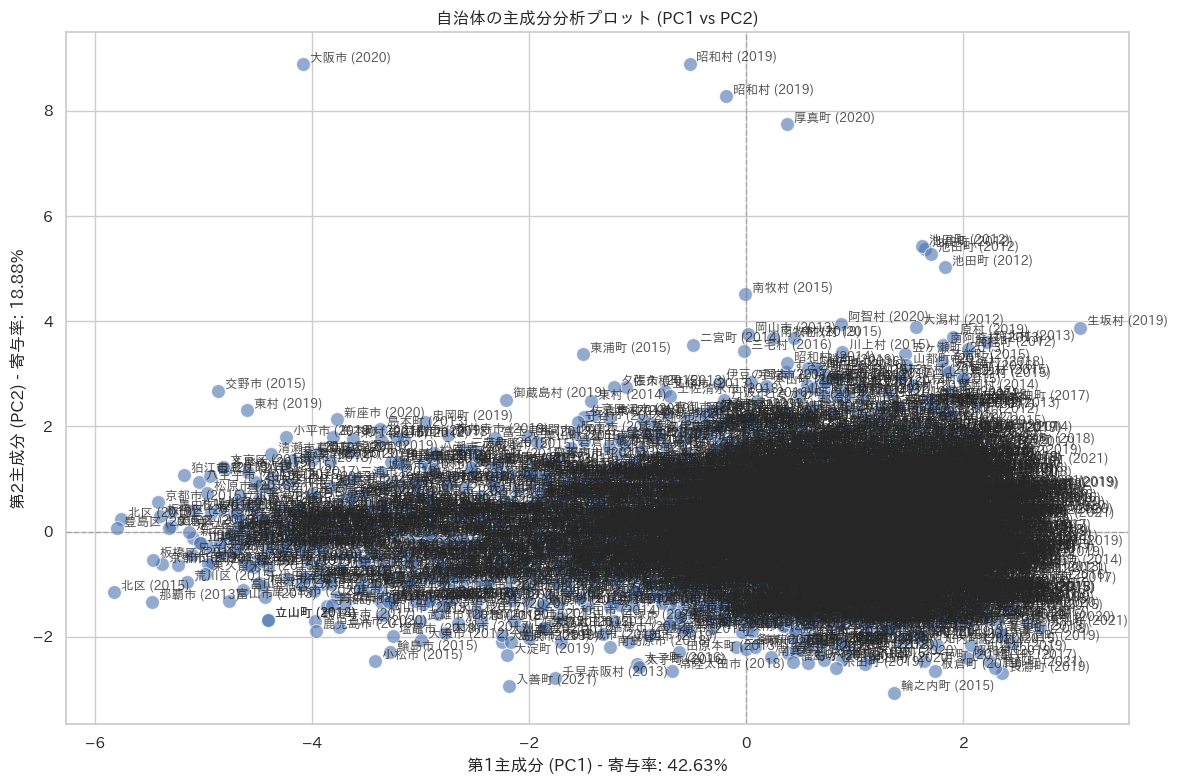

In [182]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

plt.rcParams['font.family'] = 'IPAexGothic'
# 散布図の作成
sns.scatterplot(
    data=pca_results_df, 
    x='PC1', 
    y='PC2', 
    alpha=0.6, 
    s=100
)

# 各点に市区町村名をラベル表示
for i, row in pca_results_df.iterrows():
    plt.annotate(
        row['市区町村'] + " (" + str(row['年度']) + ")", 
        (row['PC1'], row['PC2']),
        fontsize=9, 
        xytext=(5, 2), 
        textcoords='offset points',
        alpha=0.8
    )

# 軸ラベルの設定（寄与率を反映）
plt.xlabel(f"第1主成分 (PC1) - 寄与率: {ev_ratio[0]:.2%}")
plt.ylabel(f"第2主成分 (PC2) - 寄与率: {ev_ratio[1]:.2%}")
plt.title("自治体の主成分分析プロット (PC1 vs PC2)")

# 中心線の描画
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

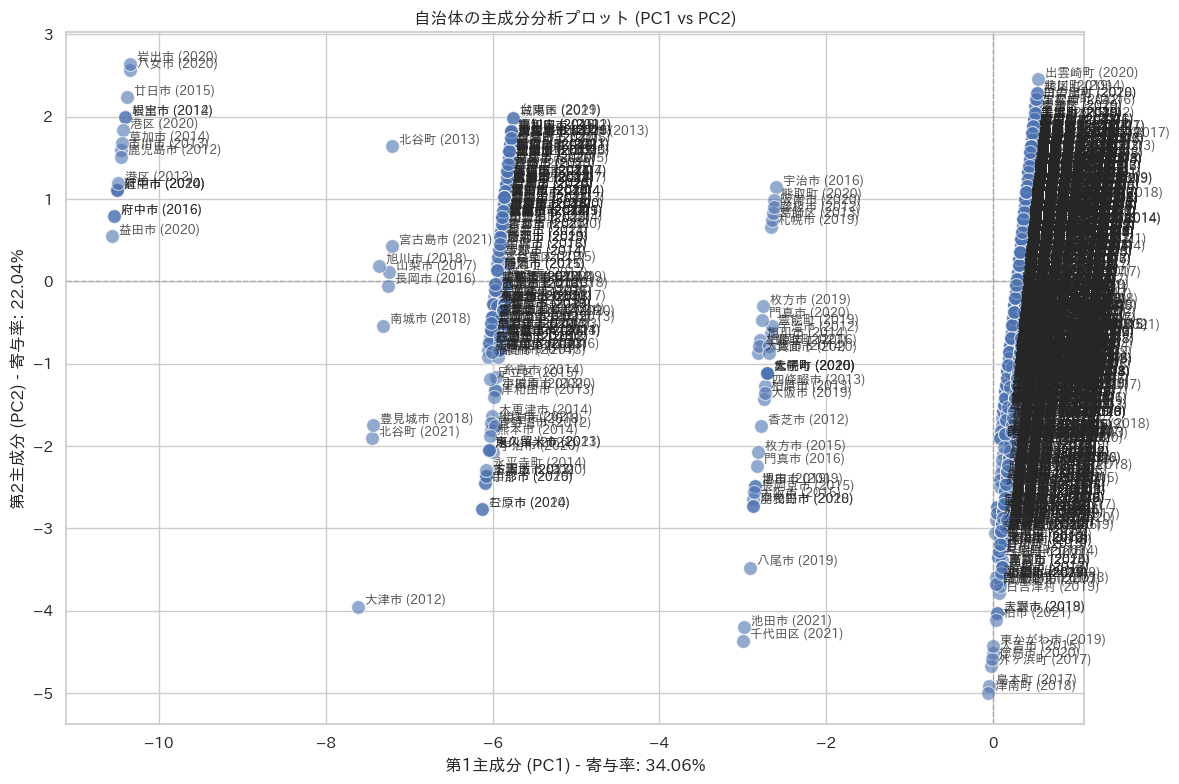

In [183]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

plt.rcParams['font.family'] = 'IPAexGothic'
# 散布図の作成
sns.scatterplot(
    data=pca_results_ch_df, 
    x='PC1', 
    y='PC2', 
    alpha=0.6, 
    s=100
)

# 各点に市区町村名をラベル表示
for i, row in pca_results_ch_df.iterrows():
    plt.annotate(
        row['市区町村'] + " (" + str(row['年度']) + ")", 
        (row['PC1'], row['PC2']),
        fontsize=9, 
        xytext=(5, 2), 
        textcoords='offset points',
        alpha=0.8
    )

# 軸ラベルの設定（寄与率を反映）
plt.xlabel(f"第1主成分 (PC1) - 寄与率: {ev_ratio_ch[0]:.2%}")
plt.ylabel(f"第2主成分 (PC2) - 寄与率: {ev_ratio_ch[1]:.2%}")
plt.title("自治体の主成分分析プロット (PC1 vs PC2)")

# 中心線の描画
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

<p>重回帰分析</p>

問題が山積み

ファイルの取得を異なる方法で行っているため変更が必要

In [184]:
df_region_code.head()

,地域コード,都道府県,市区町村
0,R01100,北海道,札幌市
1,R01202,北海道,函館市
2,R01203,北海道,小樽市
3,R01204,北海道,旭川市
4,R01205,北海道,室蘭市


In [ ]:
df_statistics 

,地域コード,年度,15~64歳人口,15~64歳人口(女),15~64歳人口(男),15歳未満人口,15歳未満人口(女),15歳未満人口(男),65歳以上の世帯員のいる核家族世帯数,65歳以上世帯員の単独世帯数,...,離婚件数,非労働力人口,非労働力人口(女),非労働力人口(男),非水洗化人口,飲食店数,高等学校数,高等学校生徒数,高齢単身世帯数(65歳以上の者1人),高齢夫婦のみの世帯数
0,R01100,2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9124.0,NaN,NaN,NaN,NaN
1,R01100,2015,1235516.0,645405.0,590111.0,221013.0,108270.0,112743.0,178246.0,NaN,...,NaN,651052.0,435482.0,215570.0,7169.0,NaN,NaN,NaN,104650.0,98660.0
2,R01100,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4096.0,NaN,NaN,NaN,7107.0,8502.0,53.0,44774.0,NaN,NaN
3,R01100,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4003.0,NaN,NaN,NaN,6549.0,NaN,52.0,44201.0,NaN,NaN
4,R01100,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4024.0,NaN,NaN,NaN,6363.0,NaN,52.0,44345.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17409,R47382,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0,NaN,NaN,NaN,13.0,NaN,0.0,0.0,NaN,NaN
17410,R47382,2020,1014.0,416.0,598.0,302.0,154.0,148.0,111.0,88.0,...,3.0,299.0,188.0,111.0,976.0,NaN,0.0,0.0,88.0,64.0
17411,R47382,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,NaN,NaN,NaN,0.0,23.0,0.0,0.0,NaN,NaN
17412,R47382,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN


In [186]:
df_final = df_final.sort_values(["地域コード", "年度"])

df_final["世帯数"] = df_final.groupby("地域コード")["世帯数"].transform(
    lambda x: x.interpolate(method="linear")
)

NameError: name 'df_final' is not defined

In [ ]:
df_final.tail(10)

NameError: name 'df_final' is not defined

<p>dfの合成</p>

In [ ]:
code_pre_df.head()

NameError: name 'code_pre_df' is not defined

In [ ]:
PCA_df_final.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0


In [ ]:
All_PCA_df = PCA_df_final.copy()

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0


In [ ]:
df_final.tail()

,地域コード,年度,市区町村,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
12183,R47382,2017,与那国町,952.0,330900.0,2927390.0
12184,R47382,2018,与那国町,888.0,419102.0,3664604.0
12185,R47382,2019,与那国町,824.0,409718.0,3885404.0
12186,R47382,2020,与那国町,760.0,412816.0,4764744.0
12187,R47382,2021,与那国町,760.0,403181.0,4259031.0


In [ ]:
All_PCA_df = All_PCA_df.merge(df_final, on=["市区町村", "年度"], how="left")

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,地域コード,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,R05327,882.8,190853.0,3073260.0
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,R05327,865.2,186964.0,2427312.0
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,R05327,847.6,191005.0,2387531.0
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,R05327,830.0,211568.0,2787409.0
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,R05327,830.0,206793.0,2850136.0


In [ ]:
All_PCA_df = All_PCA_df.merge(code_pre_df, on="地域コード", how="left")

In [ ]:
All_PCA_df.tail()

,市区町村,年度,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,地域コード,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）,都道府県
58,上小阿仁村,2017,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,R05327,882.8,190853.0,3073260.0,秋田県
59,上小阿仁村,2018,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,R05327,865.2,186964.0,2427312.0,秋田県
60,上小阿仁村,2019,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,R05327,847.6,191005.0,2387531.0,秋田県
61,上小阿仁村,2020,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,R05327,830.0,211568.0,2787409.0,秋田県
62,上小阿仁村,2021,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,R05327,830.0,206793.0,2850136.0,秋田県


In [ ]:
All_PCA_df.isna().sum()

市区町村             0
年度               0
CPC1             0
CPC2             0
期（議員）            0
CHPC1            0
CHPC2            0
期（首長）            0
地域コード            0
世帯数              0
教育費（市町村財政）       0
歳出決算総額（市町村財政）    0
都道府県             0
dtype: int64

In [ ]:
All_PCA_df = All_PCA_df[['市区町村','地域コード','年度','都道府県','CPC1','CPC2','期（議員）','CHPC1','CHPC2','期（首長）','世帯数','教育費（市町村財政）','歳出決算総額（市町村財政）']]
df_OLS = All_PCA_df.copy()

In [ ]:
All_PCA_df.tail()

,市区町村,地域コード,年度,都道府県,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,R05327,2017,秋田県,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,882.8,190853.0,3073260.0
59,上小阿仁村,R05327,2018,秋田県,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,865.2,186964.0,2427312.0
60,上小阿仁村,R05327,2019,秋田県,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,847.6,191005.0,2387531.0
61,上小阿仁村,R05327,2020,秋田県,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,830.0,211568.0,2787409.0
62,上小阿仁村,R05327,2021,秋田県,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,830.0,206793.0,2850136.0


<p>回帰分析</p>

In [ ]:
#data
df_OLS.tail()

,市区町村,地域コード,年度,都道府県,CPC1,CPC2,期（議員）,CHPC1,CHPC2,期（首長）,世帯数,教育費（市町村財政）,歳出決算総額（市町村財政）
58,上小阿仁村,R05327,2017,秋田県,1.855034,1.164243,3.0,0.021366,-0.901551,3.0,882.8,190853.0,3073260.0
59,上小阿仁村,R05327,2018,秋田県,1.855034,1.164243,4.0,0.021366,-0.901551,4.0,865.2,186964.0,2427312.0
60,上小阿仁村,R05327,2019,秋田県,2.540614,-1.129998,1.0,0.933230,1.029867,1.0,847.6,191005.0,2387531.0
61,上小阿仁村,R05327,2020,秋田県,2.540614,-1.129998,2.0,0.869769,0.862411,1.0,830.0,211568.0,2787409.0
62,上小阿仁村,R05327,2021,秋田県,2.540614,-1.129998,3.0,0.869769,0.862411,2.0,830.0,206793.0,2850136.0


In [ ]:
df_OLS = df_OLS.sort_values(["地域コード", "年度"])

In [ ]:
df_OLS['ln_教育費'] = np.log(df_OLS['教育費（市町村財政）'])
df_OLS['ln_算出決算総額'] = np.log(df_OLS['歳出決算総額（市町村財政）'])
df_OLS['ln_世帯数'] = np.log(df_OLS['世帯数'])

In [ ]:
term_dummies = pd.get_dummies(df_OLS['期（議員）'], prefix='term')

In [ ]:
term_dummies.head()

,term_1.0,term_2.0,term_3.0,term_4.0
21,1,0,0,0
22,0,1,0,0
23,0,0,1,0
24,0,0,0,1
25,1,0,0,0


In [ ]:
pc_cols = ['CPC1', 'CPC2', 'CHPC1', 'CHPC2']
interaction_vars = []

# 1期目をベースラインとして除外し、2〜4期目の交差項をループで一括作成
for pc in pc_cols:
    for s in [2.0, 3.0, 4.0]:
        col_name = f'{pc}_term_{int(s)}'
        df_OLS[col_name] = df_OLS[pc] * term_dummies[f'term_{s}']
        interaction_vars.append(col_name)

In [ ]:
df_panel = df_OLS.set_index(['市区町村', '年度'])

In [ ]:
exog_vars = interaction_vars + ['ln_算出決算総額']

In [ ]:
df_reg = df_panel[['ln_教育費'] + exog_vars].dropna()

In [ ]:
df_reg.tail()

ln_教育費  CPC1_term_2  CPC1_term_3  CPC1_term_4  CPC2_term_2  \
市区町村 年度                                                                    
長崎市  2017  16.340634     -0.00000    -0.591583    -0.000000     0.000000   
     2018  16.476082     -0.00000    -0.000000    -0.591583     0.000000   
     2019  16.679175     -0.00000    -0.000000    -0.000000    -0.000000   
     2020  16.595095     -0.70793    -0.000000    -0.000000    -0.660197   
     2021  16.606525     -0.00000    -0.707930    -0.000000    -0.000000   

           CPC2_term_3  CPC2_term_4  CHPC1_term_2  CHPC1_term_3  CHPC1_term_4  \
市区町村 年度                                                                         
長崎市  2017     0.137078     0.000000      0.000000      0.615925      0.000000   
     2018     0.000000     0.137078      0.000000      0.000000      0.615925   
     2019    -0.000000    -0.000000      0.000000      0.000000      0.000000   
     2020    -0.000000    -0.000000      0.742847      0.000000      0.000000   
     2021    -0.660197    -0.000000      0.000000      0.742847      0.000000   

           CHPC2_term_2  CHPC2_term_3  CHPC2_term_4  ln_算出決算総額  
市区町村 年度                                                         
長崎市  2017      0.000000      0.192587      0.000000  19.132183  
     2018      0.000000      0.000000      0.192587  19.151765  
     2019      0.000000      0.000000      0.000000  19.177846  
     2020      0.527499      0.000000      0.000000  19.433772  
     2021      0.000000      0.527499      0.000000  19.357169

In [ ]:
model = PanelOLS(df_reg['ln_教育費'], df_reg[exog_vars], entity_effects=True, time_effects=True)

<p>モデルは以下のようになっている</p>
<p>市区町村の効果＋時間の効果＋議会主成分１＊（それぞれの時間）＋議会主成分２＊（それぞれーー）＋首長主成分１＊（それぞれの時間）＋首長主成分２＊（それぞれの時間）＋算出決算総額log -> 教育費log</p>

In [ ]:
results = model.fit(cov_type='clustered', cluster_entity=True)

In [ ]:
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_教育費   R-squared:                        0.3325
Estimator:                   PanelOLS   R-squared (Between):              0.8598
No. Observations:                  63   R-squared (Within):               0.4558
Date:                Fri, Apr 10 2026   R-squared (Overall):              0.8598
Time:                        02:22:59   Log-likelihood                    58.477
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.3409
Entities:                           9   P-value                           0.2372
Avg Obs:                       7.0000   Distribution:                   F(13,35)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):          1.296e+14
                            

In [ ]:
with open("regression_results.txt", "w", encoding="utf-8") as f:
    f.write(results.summary.as_text())

print("結果を regression_results.txt に保存しました！")

結果を regression_results.txt に保存しました！
